In [36]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")
print(df.shape)
print(df['Class'].value_counts())
print(df.head(3))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  
2 -0.139097 -0.055353 -0.059752  378.66      0  

[3 rows x 31 columns]


In [37]:
#find null values
df.isnull().sum().max()

0

In [38]:
# find percentage of fraud and not fraud class in the data
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


C:\Users\milli\AppData\Local\Temp\ipykernel_24544\1379996910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)
c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  d

Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

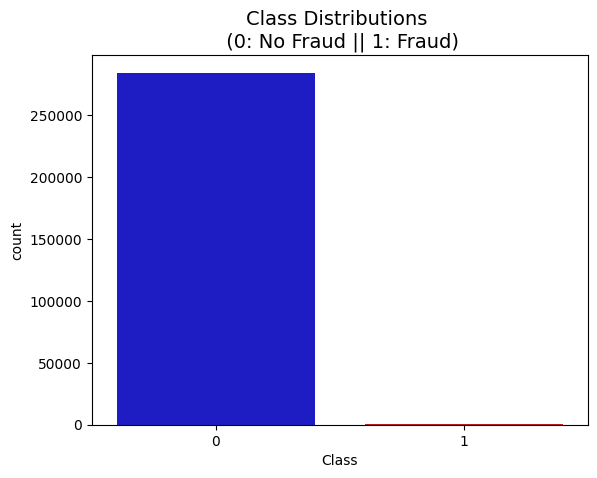

In [39]:
# Visualize the Class values 
import matplotlib.pyplot as plt
import seaborn as sns
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

In [40]:
# The target column is imbalanced
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [41]:
# creating a balanced dataset Before or without Train test split for EDA and visualization
import pandas as pd

# 1. All fraud rows
fraud = df[df['Class'] == 1]

# 2. Same number of non-fraud rows, sampled randomly
non_fraud = df[df['Class'] == 0].sample(n=len(fraud), random_state=42)

# 3. Combine them into one smaller, balanced dataset
df_small = pd.concat([fraud, non_fraud], axis=0)

fraud_small = df_small[df_small['Class'] == 1]
nonfraud_small = df_small[df_small['Class'] == 0]

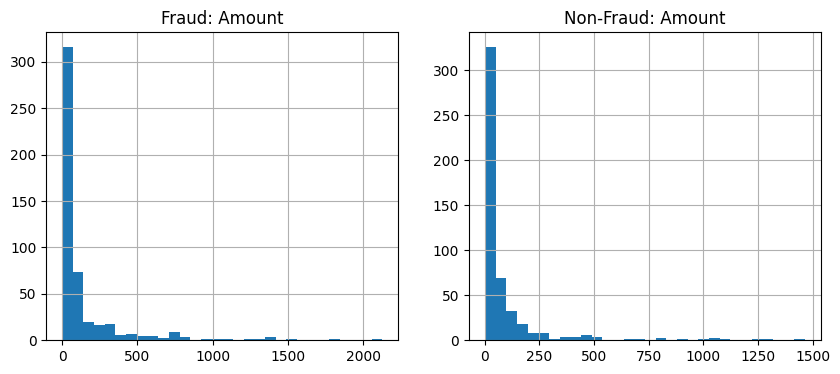

In [42]:
# checking to see if Amount column is an important feature in identifying Class
# here we see that the bars almost overlap, so Amount is not a strong indicator
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
fraud_small['Amount'].hist(bins=30)
plt.title('Fraud: Amount')

plt.subplot(1, 2, 2)
nonfraud_small['Amount'].hist(bins=30)
plt.title('Non-Fraud: Amount')

plt.show()

In [43]:
# finding which features gives the most strong signal when compared between fraud vs non-fraud class
# Also performing Train Test Split here
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # helps with the imbalance
)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance.head(10))

V14    0.172755
V4     0.115382
V10    0.111231
V12    0.093417
V17    0.092719
V3     0.064234
V11    0.058795
V16    0.051311
V2     0.028824
V7     0.025840
dtype: float64


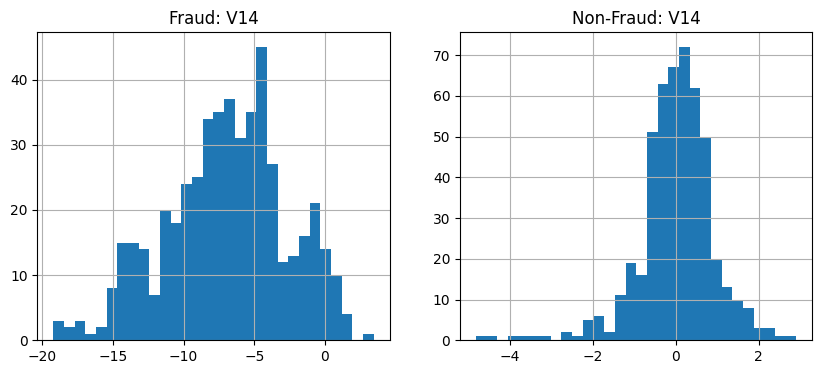

In [44]:
# checking to see the overlap with V14 column 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
fraud_small['V14'].hist(bins=30)
plt.title('Fraud: V14')

plt.subplot(1, 2, 2)
nonfraud_small['V14'].hist(bins=30)
plt.title('Non-Fraud: V14')

plt.show()

#shows that V14 is an important feature in identifying fraud from non-fraud 

In [45]:
# Train a model to create predictions with imblanced data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Original Logistic Regression on full imbalanced training set
log_reg_orig = LogisticRegression(max_iter=1000, random_state=42)
log_reg_orig.fit(X_train, y_train)

# Predictions on the original test set
y_pred_original = log_reg_orig.predict(X_test)

# (Optional) check classification report to confirm it matches your screenshot
print("Original model (imbalanced training) report:")
print(classification_report(y_test, y_pred_original, digits=4))

Original model (imbalanced training) report:
              precision    recall  f1-score   support

           0     0.9995    0.9998    0.9996     56864
           1     0.8590    0.6837    0.7614        98

    accuracy                         0.9993     56962
   macro avg     0.9292    0.8417    0.8805     56962
weighted avg     0.9992    0.9993    0.9992     56962



c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
# Create a Confusion Matrix from the predicted values
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0 (non-fraud)', 'Actual 1 (fraud)'],
    columns=['Pred 0 (non-fraud)', 'Pred 1 (fraud)']
)
print(cm_df)

                      Pred 0 (non-fraud)  Pred 1 (fraud)
Actual 0 (non-fraud)               56853              11
Actual 1 (fraud)                      31              67


In [47]:
# creating a balanced dataset with training set for traning the model 
import pandas as pd

# Make one training DataFrame so we can filter by Class easily
train_df = X_train.copy()
train_df["Class"] = y_train.values

# Separate fraud and non-fraud rows
fraud_df = train_df[train_df["Class"] == 1]
non_fraud_df = train_df[train_df["Class"] == 0]

# Randomly sample non-fraud rows to match the number of fraud rows
non_fraud_sample = non_fraud_df.sample(n=len(fraud_df), random_state=42)

# Combine fraud rows + sampled non-fraud rows
balanced_train_df = pd.concat([fraud_df, non_fraud_sample], axis=0)

# Shuffle the rows
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split back into X and y
y_train_balanced = balanced_train_df["Class"]
X_train_balanced = balanced_train_df.drop("Class", axis=1)

# Optional: check the class counts
print(y_train_balanced.value_counts())

Class
0    394
1    394
Name: count, dtype: int64


In [ ]:
# Creating a undersampled training dataset and then get a confusion matrix and its metrics
# keep all fraud rows and randomly drop the majority non-fraud rows until the counts match the fraud rows
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train on the balanced training data
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42)
log_reg_balanced.fit(X_train_balanced, y_train_balanced)

# 2. Predict on the original (imbalanced) test set
y_pred_balanced = log_reg_balanced.predict(X_test)

# 3. Evaluate: confusion matrix and classification report
print("Confusion matrix (balanced-trained model on original test set):")
print(confusion_matrix(y_test, y_pred_balanced))
print()

print("Classification report (balanced-trained model on original test set):")
print(classification_report(y_test, y_pred_balanced, digits=4))

Confusion matrix (balanced-trained model on original test set):
[[54494  2370]
 [    8    90]]

Classification report (balanced-trained model on original test set):
              precision    recall  f1-score   support

           0     0.9999    0.9583    0.9786     56864
           1     0.0366    0.9184    0.0704        98

    accuracy                         0.9583     56962
   macro avg     0.5182    0.9383    0.5245     56962
weighted avg     0.9982    0.9583    0.9771     56962



c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# balanced dataset - created by assigning more weight to the fraud rows because they are rare.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train Logistic Regression with class weights on original imbalanced training set
log_reg_weighted = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
log_reg_weighted.fit(X_train, y_train)

# 2. Predict on original (imbalanced) test set
y_pred_weighted = log_reg_weighted.predict(X_test)

# 3. Evaluate
print("Confusion matrix (class_weight='balanced' model on original test set):")
print(confusion_matrix(y_test, y_pred_weighted))
print()

print("Classification report (class_weight='balanced' model on original test set):")
print(classification_report(y_test, y_pred_weighted, digits=4))

c:\Users\milli\Desktop\CodeForGit\1BIProjects\portfolio-projects\ML\Credit-Fraud\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion matrix (class_weight='balanced' model on original test set):
[[55416  1448]
 [    8    90]]

Classification report (class_weight='balanced' model on original test set):
              precision    recall  f1-score   support

           0     0.9999    0.9745    0.9870     56864
           1     0.0585    0.9184    0.1100        98

    accuracy                         0.9744     56962
   macro avg     0.5292    0.9465    0.5485     56962
weighted avg     0.9982    0.9744    0.9855     56962



In [50]:
# compare imbalanced, undersampled and balanced
from sklearn.metrics import classification_report
import pandas as pd

reports = {
    "original": classification_report(y_test, y_pred_original, output_dict=True),
    "undersampled": classification_report(y_test, y_pred_balanced, output_dict=True),
    "class_weight": classification_report(y_test, y_pred_weighted, output_dict=True),
}

rows = ["1"]  # fraud class only
metrics = ["precision", "recall", "f1-score"]

data = {}
for name, rep in reports.items():
    data[name] = [rep["1"][m] for m in metrics]

comparison_fraud = pd.DataFrame(data, index=metrics)
print(comparison_fraud)

           original  undersampled  class_weight
precision  0.858974      0.036585      0.058518
recall     0.683673      0.918367      0.918367
f1-score   0.761364      0.070367      0.110024
